# Neural SPDE, depth-stepped over 2D calorimeter showers (CaloChallenge Dataset 2, SiW)

A Neural SPDE (Salvi, Lemercier & Gerasimovics, 2021, arXiv:2110.10249 -- learned
*spatial operators* solving a stochastic PDE) applied to 3D voxelized calorimeter
shower data, reading the voxel grid `(Z, PHI, R) = (45, 16, 9)` as a **(2+1)-
dimensional space-time domain**: the transverse `(PHI, R)` plane is the 2D space,
and the Z-depth axis (the 45 calorimeter layers) is time. A shower is generated by
solving

```
dy = f_theta(t, y) dt + g_theta(t, y) . noise
```

forward from layer 0 to layer 44, where `y` is the *energy fraction*
(`shower_MeV / E_inc_MeV`, linear, not log-normalized) deposited per voxel,
`f_theta`/`g_theta` ("drift"/"diffusion") are learned FNO-style spectral operators
over the `(PHI, R)` plane, and the driving noise is a **pluggable stochastic
process** -- `BrownianNoise` / `ColoredBrownianNoise` (Wiener-driven) or
`CompoundPoissonNoise` (jump-driven, closer to true shot noise) -- selected via
`CFG["noise_type"]`. See `nspde2d_voxel.py`'s module docstring for the full
derivation and `README.md` for the design rationale.

This directly extends `../sde_demo.ipynb`'s `CaloSDE` prototype (a fixed
mean-reversion drift + fixed `sqrt(E)` shot-noise diffusion, integrated with
`torchsde`) by replacing both fixed functional forms with learned spectral
networks, and by making the driving noise process itself swappable.

**Single geometry, by design**: CaloChallenge Dataset 2 (SiW), fixed incidence
(`theta=pi/2, phi=0`) -- this validates the architecture itself before adding
`cfm-dit_voxel`'s multi-geometry conditioning (`geom_id`, variable `phi`/`theta`)
on top.

## Code layout

- **`nspde2d_voxel.py`** -- all model code: spectral operator layers
  (`SpectralConv2d`, `FourierLayer2d`, `SpatialOperator`), the three
  `NoiseProcess` implementations, `NeuralSPDE` (the full model), and the
  `train`/`load_nspde_checkpoint`/`generate_nspde` helpers. Import from here
  rather than redefining anything inline.
- **`nspde2d-voxel.ipynb`** (this file) -- config (`CFG`), data loading (a custom
  energy-fraction normalization -- *not* `../utilities.py`'s log-normalization,
  see the Dataset section below), training/eval orchestration, plots.
- **`../utilities.py`** -- reused only for `CaloChallenge` (raw HDF5 loading) and
  the shared plotting helpers (`plot_z_profiles`, `plot_comparison`); the
  normalization transform itself is written fresh in this notebook.


In [1]:
# from google.colab import drive
# drive.mount('/content/drive')


In [2]:
%pip install --upgrade pip -qqq
%pip install h5py wandb -qqq


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [3]:
import math
import sys
import h5py
import numpy as np
import torch
import wandb
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

sys.path.append("../")
from utilities import CaloChallenge, plot_z_profiles, plot_comparison

torch.backends.cudnn.benchmark = True   # fixed input shapes (voxel_shape, drop_last=True) -- let cuDNN autotune kernels
torch.cuda.empty_cache()


In [4]:
CFG = dict(
    # --- data: single geometry (CaloChallenge Dataset 2, SiW), fixed incidence ---
    # This first Neural SPDE version is single-geometry by design, to validate the
    # architecture itself before adding cfm-dit_voxel's multi-geometry conditioning
    # (geom_id, variable phi/theta) on top -- see README.md.
    data_path   = "../../calo-data/dataset_2_1.hdf5",
    test_data_path = "../../calo-data/dataset_2_2.hdf5",   # ground truth for eval only, not read by the train/test loaders
    n_samples   = None,
    voxel_shape = (45, 16, 9),   # (T, H, W) = (Z-depth "time", PHI, R) -- see nspde2d_voxel.py module docstring

    # --- model (learned spectral drift + diffusion operators) ---
    hidden_dim       = 64,
    n_fourier_layers = 4,
    modes_h          = 8,    # PHI-axis spectral modes kept (out of 16)
    modes_w          = 5,    # R-axis spectral modes kept (all of them: W//2+1 = 5 for W=9)
    cond_dim         = 128,
    time_dim         = 32,
    compile          = False,   # torch.compile: leave off until shapes/noise_type are settled

    # --- driving noise process -- swap this to compare, per your request. Changing
    # it changes what diffusion_net's output *means* (Gaussian std vs. Poisson
    # rate), so a checkpoint trained with one noise_type is NOT compatible with
    # another -- ckpt_dir below is keyed by noise_type specifically so switching
    # doesn't overwrite or mix checkpoints between them. See nspde2d_voxel.py's
    # NoiseProcess subclasses (BrownianNoise / ColoredBrownianNoise /
    # CompoundPoissonNoise) for what each one actually does.
    noise_type = "poisson",   # "brownian" | "colored_brownian" | "poisson"
    init_quantum = 1e-4,   # CompoundPoissonNoise: sets mean_jump=rate*dt*quantum at init.
                            # Recalibrated for the current loss design (ground-truth-scaled
                            # Huber, not a plain NLL) -- 0.05 (tuned for the old design) gave
                            # an initial mean_jump way too large relative to the correctly-tiny
                            # scale of the ~75%-sparse majority, stalling training from epoch 1.
                            # See README.md "Known issues" for the full loss-redesign story.
    drift_reg_weight = 0.05,   # Penalizes drift_dt directly (relative to the same ground-
                                # truth scale as everything else) so it can only act as a minor
                                # correction, not absorb the bulk of mean-fitting the way an
                                # unconstrained drift_net did (confirmed: rate/quantum stayed
                                # near their random init for a full 30-epoch run otherwise).
    drift_pos_mult = 1.0,   # Asymmetry on top of drift_reg_weight (positive/energy-injecting
                             # drift_dt penalized this much harder than negative/containment
                             # drift_dt); 1.0 = neutral, mathematically identical to the
                             # original plain-L2 penalty. Tried at 10.0 to fix a confirmed
                             # drift-sign-flip bug past shower-max -- it did fix that specific
                             # symptom, but the resulting checkpoint was WORSE overall: it just
                             # shifted the same mean-fitting burden onto CompoundPoissonNoise's
                             # rate net, whose predicted rate then stopped decaying with depth
                             # and grew into a genuine positive-feedback runaway instead (per-hit
                             # EMD at 1 TeV went 135->670; longitudinal profile went from
                             # plateauing to exploding to ~4x the real peak). Reverted to 1.0
                             # pending a real fix (per-depth-layer aggregate loss, or cumulative-
                             # deposited-energy conditioning) -- see README.md "Known issues" and
                             # teacher_forced_loss's docstring in nspde2d_voxel.py for the full
                             # story and the numbers behind it.
    global_reg_weight = 5.0,   # EXPERIMENT (2026-09-02), bumped from 1.0: the cum_frac-conditioned
                                # 2026-09-01 13:06 run undershot true containment by ~10x (right
                                # shape) even with this term active at weight 1.0 -- raising it is
                                # the cheapest next thing to rule out before building anything new.
                                # Caveat, worth knowing going in: this term is computed from
                                # teacher-forced per-step predictions (real y_t as input), same as
                                # every other term here -- it doesn't see the free-running rollout,
                                # so it may not fully close a gap that's fundamentally an exposure-
                                # bias/compounding-over-44-steps problem. See README.md "Known
                                # issues" for the two prior attempts (cum_frac conditioning alone,
                                # then + scheduled_sampling_prob) and why the second one -- now
                                # disabled below -- made things worse (~30x OVER-containment)
                                # rather than better.
                                # Per-shower aggregate loss matching total predicted energy added
                                # (summed over all voxels/layers) against the real total -- the
                                # per-voxel auxiliary loss alone still let ~75% correctly-zero
                                # voxels dilute the signal from the rarer voxels carrying real
                                # energy (confirmed: generated showers landed ~180x under target
                                # even with per-voxel rate/quantum looking reasonable).

    # --- cumulative-energy conditioning (kept -- fixed the z-profile SHAPE, confirmed on a
    # 2026-09-01 retrain: z-profiles now decay past shower-max instead of plateauing/growing).
    # See CumulativeEnergyEmbedding / teacher_forced_loss's "UPDATE" docstring paragraph.
    #
    # scheduled_sampling_* is DISABLED below (scheduled_sampling_start_epoch=None) -- the
    # 2026-09-01 15:17 run that turned it on made containment much WORSE, not better: ~30x
    # OVER-containment (versus ~10x under without it), plus the z-profile shape broke too
    # (overshoots real peak by 5-15x, barely decays even by layer 44). Root cause, from that
    # run's own training curves (wandb run 78vkb5xr): once ss_prob climbed past ~0.4 (epoch
    # ~65-70), grad_norm spiked 10x and train_loss got WORSE even as test_loss (pure teacher
    # forcing, unaffected by scheduled sampling) kept improving to the best value of any run
    # so far -- meaning the self-rollout cum_frac fed into the scheduled-sampling half of
    # training was itself systematically biased (inheriting this architecture's own
    # under-containment tendency during the early/mid part of training) and taught the
    # networks to *compensate* for a low-looking cum_frac by injecting more energy, which
    # combined with the rate net's known y-conditioned positive-feedback vulnerability (see
    # drift_pos_mult's comment above) into a runaway at generation time. See README.md "Known
    # issues" for the full numbers. Left implemented (not deleted) in nspde2d_voxel.py in
    # case a more careful version (e.g. blending real/self-rollout cum_frac instead of full
    # replacement, or gating on the self-rollout's own total-energy accuracy) is worth
    # revisiting later -- just not turned on for this run.
    scheduled_sampling_start_epoch = None,
    scheduled_sampling_ramp_epochs = 40,
    scheduled_sampling_max_prob    = 0.5,

    # --- SPDE integration ---
    dt = 1.0,   # one unit of "time" per depth layer, T=45 steps total (matches sde_demo.ipynb's t_steps convention)

    # --- training ---
    epochs        = 100,
    batch_size    = 32,    # showers/batch -- each expands to batch_size*(T-1) transitions per
                            # step via teacher forcing (see teacher_forced_loss), so this is
                            # deliberately smaller than cfm-dit_voxel's 256 (which has no such
                            # per-sample multiplier)
    lr            = 6e-4,  # untuned starting point, borrowed from cfm-dit_voxel -- a very
                            # different architecture/loss, so treat this as a first guess
    warmup_epochs = 10,
    grad_clip     = 1.0,
    grad_skip_mult= 20000, # Higher than the 1000 originally used with the old plain-NLL
                            # design -- the current Huber-bounded loss legitimately produces
                            # larger (but bounded, non-runaway) gradients early in training;
                            # 1000 caused false-positive stalls (confirmed stable, non-escalating
                            # grad_norm in the 1000-5000 range that 1000 alone would reject).
                            # Every *applied* update is still clipped to grad_clip=1.0 regardless.
    skip_patience = 5,      # slightly more lenient than the default 3 -- validated at 5
                            # during the loss redesign, gives a bit more tolerance for
                            # transient outlier batches without delaying real-stall detection.
    device        = "cuda" if torch.cuda.is_available() else "cpu",
    log_every     = 10,
    seed          = 1234,

    # --- checkpointing ---
    mode      = "train",   # "train": fresh start, ignoring any existing checkpoints;
                            # "resume": continue training from the latest checkpoint in
                            # ckpt_dir (must exist); "eval": load the latest checkpoint,
                            # no training. See nspde2d_voxel.py's train()/load_nspde_checkpoint.
                            # Must be "train" here too -- the latest checkpoint was trained
                            # with scheduled sampling and already encodes the ~30x-over
                            # equilibrium that turning scheduled sampling back off wouldn't
                            # undo by resuming.
    save_every= 50,

    # --- wandb logging ---
    wandb_log    = 1,
    wandb_project= "nspde2d_voxel",
    wandb_entity = "pgeorgantopoulos-ntua",
)
CFG["ckpt_dir"] = f"checkpoints/{CFG['noise_type']}"   # keyed by noise_type -- see comment above


In [5]:
if CFG["wandb_log"]:
    wandb.init(project=CFG["wandb_project"], entity=CFG["wandb_entity"], config=CFG)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pgeorgantopoulos/.netrc.


wandb: Currently logged in as: pgeorgantopoulos (pgeorgantopoulos-ntua) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Tracking run with wandb version 0.26.1


wandb: Run data is saved locally in /home/pgeorgantopoulos/cern/fastsim/nspde2d-voxel/wandb/run-20260902_105255-ruen8lbv
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run unique-frost-18


wandb: ⭐️ View project at https://wandb.ai/pgeorgantopoulos-ntua/nspde2d_voxel


wandb: 🚀 View run at https://wandb.ai/pgeorgantopoulos-ntua/nspde2d_voxel/runs/ruen8lbv


## Dataset

`CaloChallenge` (in `../utilities.py`) reads the HDF5 file and reshapes each flat
voxel row to `(R, PHI, Z)` via `HighLevelFeatures`' binning. The normalization
here is custom (not `ddim_calochallenge_dataloaders`'s log-normalization to
`[-1,1]`): `y = shower_MeV / E_inc_MeV`, kept **linear**, since the SPDE's
additive drift + multiplicative diffusion are only physically meaningful in
linear energy space (see `nspde2d_voxel.py`'s module docstring). Each sample
returns the **full** `(T, 1, H, W)` sequence (all 45 layers), since
`teacher_forced_loss` needs every layer to score all `T-1` transitions at once.


In [6]:
sys.path.append("../CaloChallenge/code/")
from HighLevelFeatures import HighLevelFeatures

hlf = HighLevelFeatures('electron', filename='../CaloChallenge/code/binning_dataset_2.xml')

train_raw, test_raw = CaloChallenge.from_config(CFG, hlf, train_split=0.8)

EPS = 1e-6

def forward(shower, energy_mev):
    shower = shower.transpose(2, 1, 0)                      # (R, PHI, Z) -> (Z, PHI, R) = (T, H, W)
    y = shower / (float(energy_mev) + EPS)                  # energy *fraction* of E_inc -- linear, not log
    y = torch.from_numpy(y).unsqueeze(1).float()             # (T, 1, H, W)
    cond = math.log10(float(energy_mev) + EPS)
    return y, torch.tensor(cond, dtype=torch.float32), torch.tensor(float(energy_mev), dtype=torch.float32)

def inverse(y_norm, e_inc_mev):
    # State is already linear (energy fraction), so the inverse is just a rescale
    # by E_inc -- no log/exp needed, unlike the sibling models' log-normalization.
    return y_norm * e_inc_mev[:, None, None, None, None]

train_raw.transform = test_raw.transform = forward

train_loader = DataLoader(train_raw, batch_size=CFG["batch_size"], shuffle=True,
                           num_workers=2, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_raw,  batch_size=CFG["batch_size"], shuffle=False,
                           num_workers=2, pin_memory=True, drop_last=False)


Features in dataset_2_1.hdf5: ['incident_energies', 'showers']


Showers shape: (80000, 6480)
Incident energies shape: (80000, 1)


showers_4d shape: (80000, 9, 16, 45)


Features in dataset_2_1.hdf5: ['incident_energies', 'showers']


Showers shape: (20000, 6480)
Incident energies shape: (20000, 1)


showers_4d shape: (20000, 9, 16, 45)
Train: 80000 | Test: 20000


## Model

In [7]:
from nspde2d_voxel import (
    NeuralSPDE, SpectralConv2d, FourierLayer2d, SpatialOperator, InitialFieldNet,
    BrownianNoise, ColoredBrownianNoise, CompoundPoissonNoise, build_noise_process, build_model,
)


## Train

In [8]:
from nspde2d_voxel import train, load_nspde_checkpoint, generate_nspde

if CFG["mode"] in ("train", "resume"):
    model, loss_history, test_loss_history = train(CFG, train_loader, test_loader)


  Noise process : poisson
  Parameters    : 2.94 M
  VRAM          : 0.021 GiB


  skip_frac=0.00%


  skip_frac=0.00%


  skip_frac=0.00%


  skip_frac=0.00%


...

  skip_frac=0.00%


  skip_frac=0.00%


  skip_frac=0.00%


  skip_frac=0.00%


Epoch  100/100  |  loss=0.00752  grad_norm(mean/max)=0.728/5.949  test_loss=0.00717  lr=1.00e-06
  -> saved checkpoints/poisson/ckpt2026-09-02_14-25_epoch0100.pt


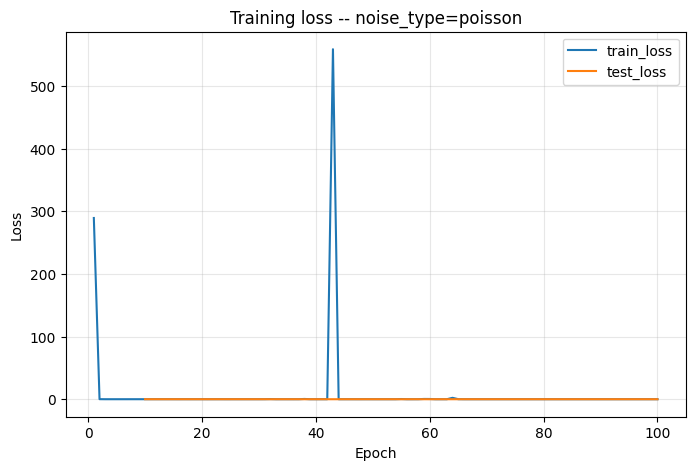

In [9]:
# Local loss-curve plot (not logged to wandb -- train() already logs
# train_loss/test_loss/grad_norm/skip_frac to wandb every epoch).
if CFG["mode"] in ("train", "resume"):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(loss_history) + 1), loss_history, label="train_loss")
    if test_loss_history:
        test_epochs, test_losses = zip(*test_loss_history)
        plt.plot(test_epochs, test_losses, label="test_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training loss -- noise_type={CFG['noise_type']}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


## Load pretrained model

In [10]:
if CFG["mode"] == "eval":
    model, loaded_cfg = load_nspde_checkpoint(CFG)


## Eval

### E_INC sweep -- generation

In [11]:
ENERGIES_GEV = [1, 10, 100, 1000, 2000]
N_SWEEP = 100

sweep_gen = {}
for e_gev in ENERGIES_GEV:
    sweep_gen[e_gev] = generate_nspde(model, CFG, inverse, n_samples=N_SWEEP, e_inc_gev=e_gev)
    print(f"E_inc={e_gev:5d} GeV -> generated {sweep_gen[e_gev].shape}  "
          f"(min={sweep_gen[e_gev].min():.3e}, max={sweep_gen[e_gev].max():.3e} MeV)")


E_inc=    1 GeV -> generated (100, 45, 1, 16, 9)  (min=0.000e+00, max=1.123e+00 MeV)
E_inc=   10 GeV -> generated (100, 45, 1, 16, 9)  (min=0.000e+00, max=8.768e+00 MeV)
E_inc=  100 GeV -> generated (100, 45, 1, 16, 9)  (min=0.000e+00, max=6.006e+01 MeV)


E_inc= 1000 GeV -> generated (100, 45, 1, 16, 9)  (min=0.000e+00, max=4.282e+02 MeV)
E_inc= 2000 GeV -> generated (100, 45, 1, 16, 9)  (min=0.000e+00, max=8.545e+02 MeV)


In [12]:
# Ground truth for the sweep, pulled directly from the held-out test file (never
# read by train_loader/test_loader above) via an energy-window mask -- same
# pattern cfm-dit_voxel/ddim-t_voxel use for their own E_INC sweeps.
test_gt = CaloChallenge(CFG["test_data_path"], hlf)          # (K, R, PHI, Z) raw MeV, (K,) MeV

def ground_truth_for(e_gev, rtol=0.05):
    target_mev = e_gev * 1e3
    mask = np.isclose(test_gt.energies, target_mev, rtol=rtol)
    return test_gt.showers[mask]                              # (k, R, PHI, Z)


Features in dataset_2_2.hdf5: ['incident_energies', 'showers']


Showers shape: (100000, 6480)
Incident energies shape: (100000, 1)


showers_4d shape: (100000, 9, 16, 45)


### Z-profiles (depth = the SPDE's own time axis)

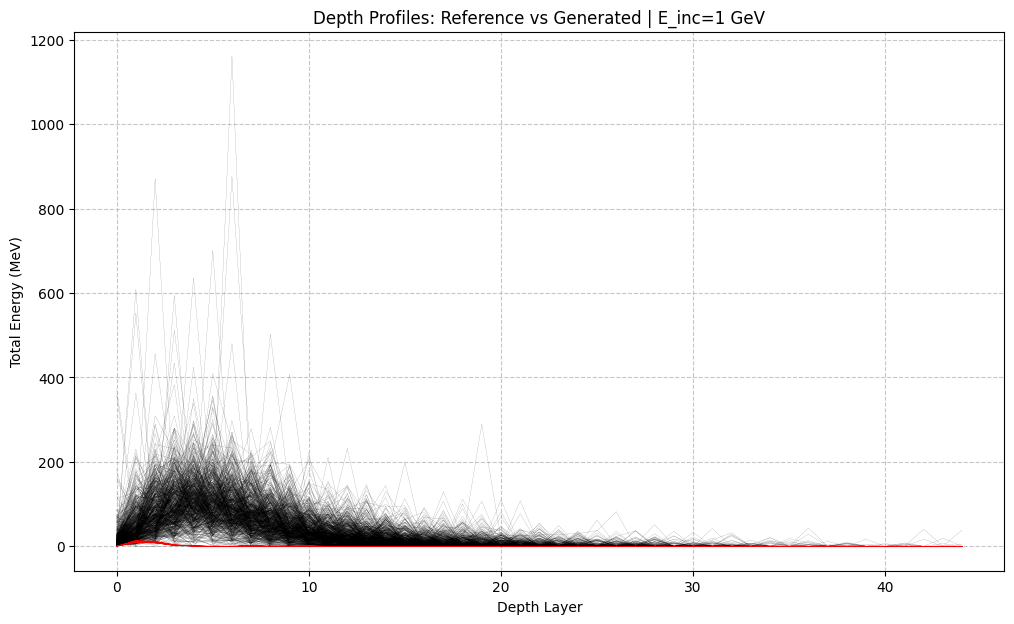

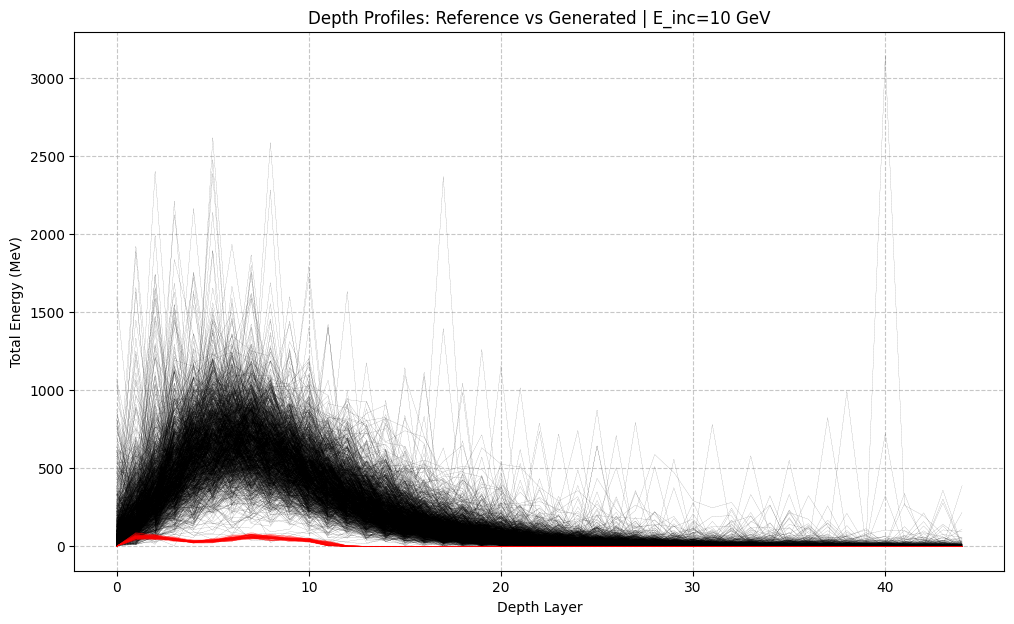

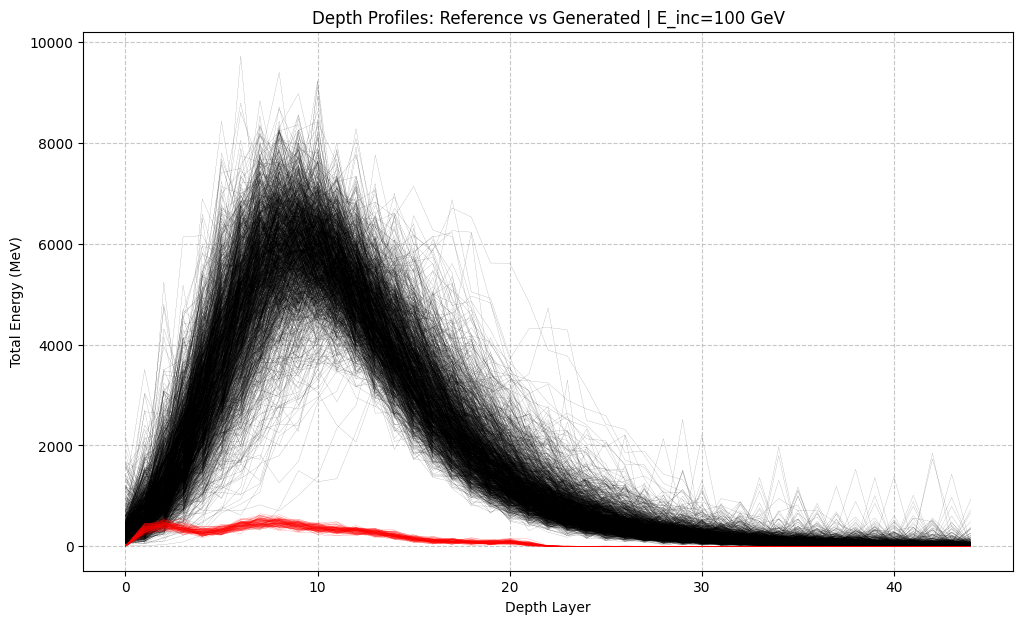

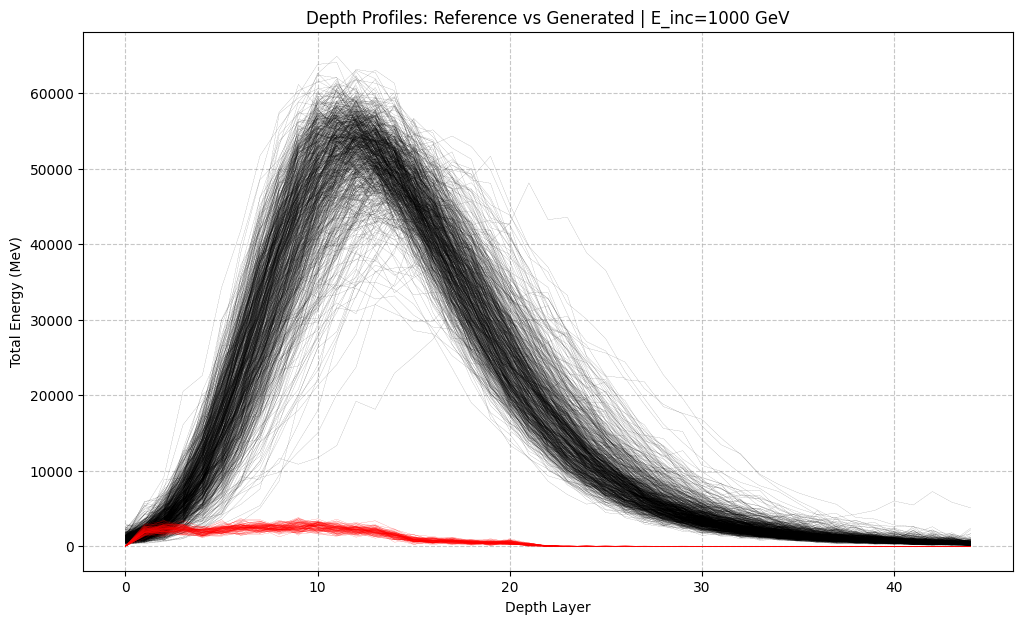

E_inc=2000 GeV: no ground-truth showers matched, skipping


In [13]:
for e_gev in ENERGIES_GEV:
    gen = sweep_gen[e_gev][:, :, 0]                           # (N, T, H, W) -- drop channel dim
    gt  = ground_truth_for(e_gev).transpose(0, 3, 2, 1)        # (k, R,PHI,Z) -> (k, Z,PHI,R) = (k, T, H, W)
    if len(gt) == 0:
        print(f"E_inc={e_gev} GeV: no ground-truth showers matched, skipping")
        continue
    fig, ax = plot_z_profiles(gt, gen_showers=gen, filename=f"E_inc={e_gev} GeV", transverse_axes=(2, 3))
    if wandb.run is not None:
        wandb.log({f"z_profile_{e_gev}GeV": wandb.Image(fig)})
    plt.show()


### Energy distribution + radial profile comparison

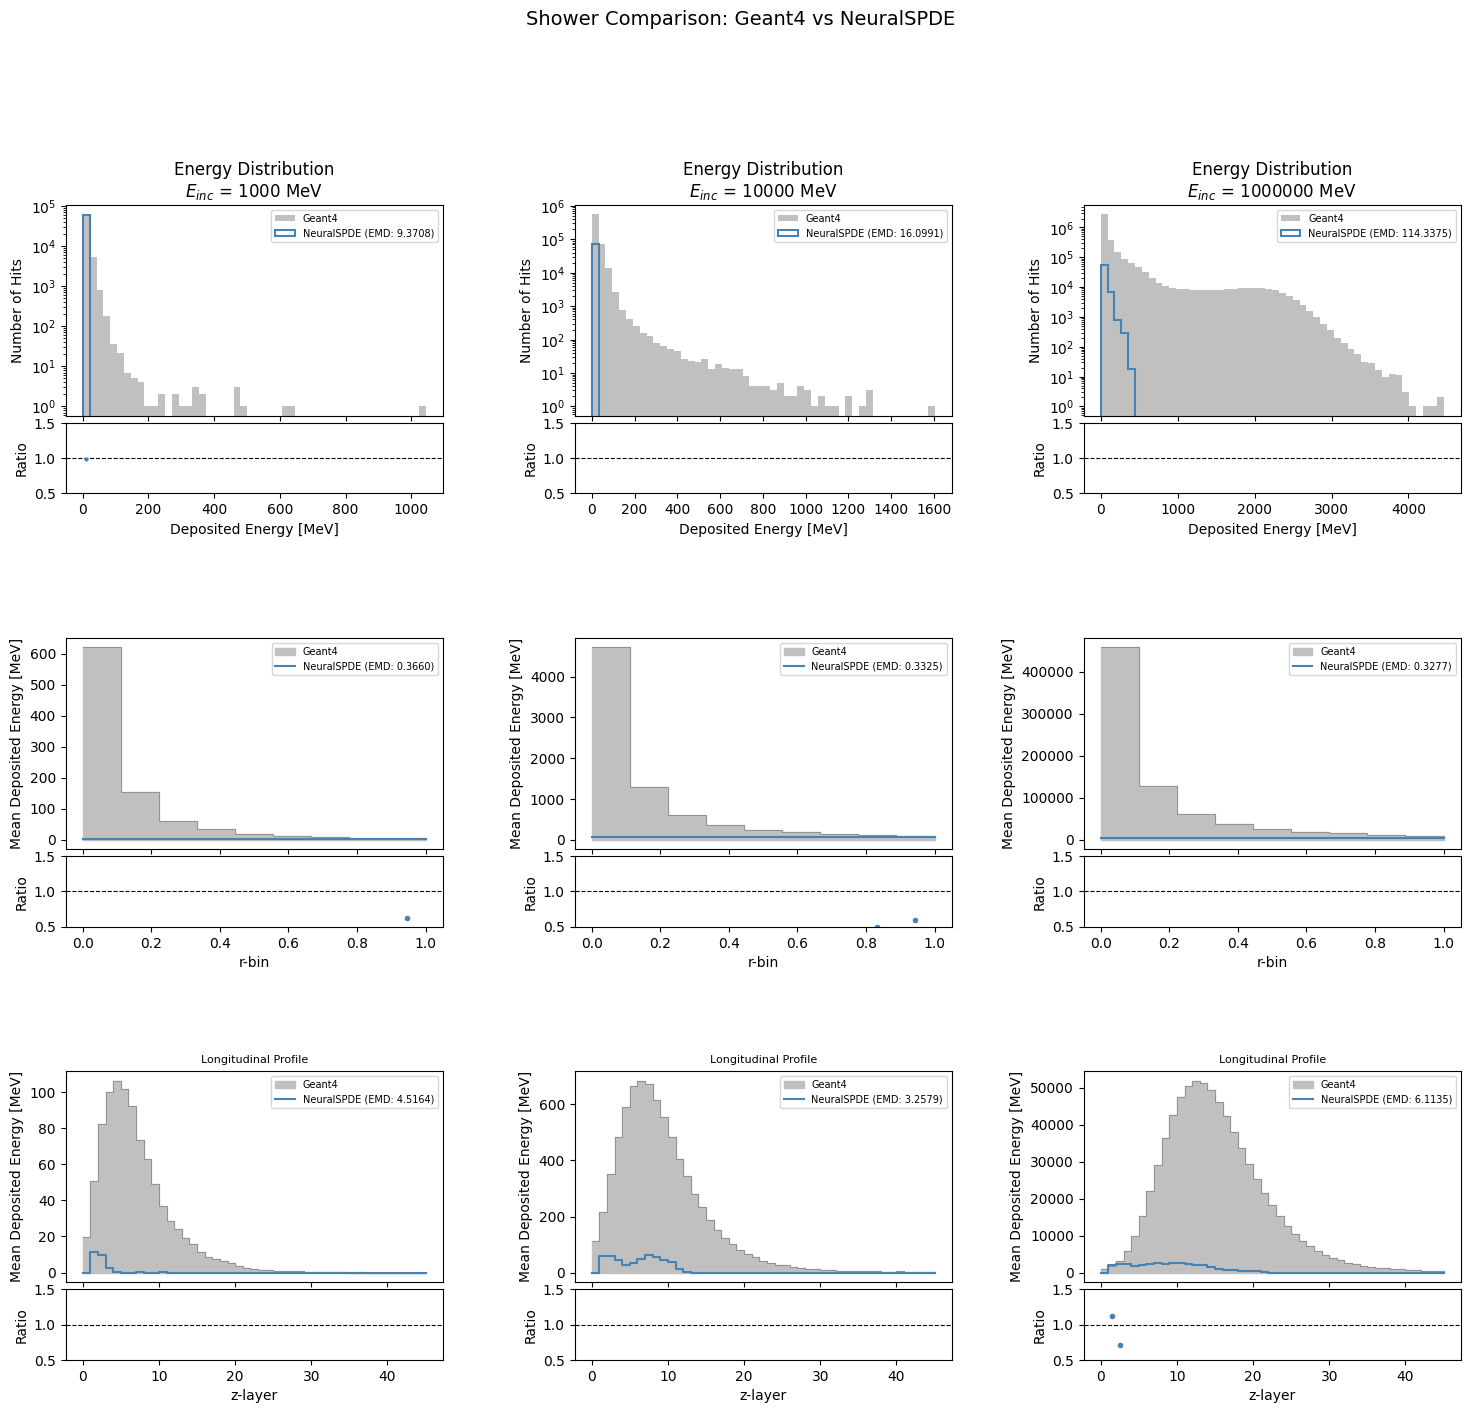

In [14]:
def to_rphiz(x_tzhw):
    # (N, T, H, W) = (N, Z, PHI, R) -> (N, R, PHI, Z), matching plot_comparison's expected layout
    return x_tzhw.transpose(0, 3, 2, 1)

all_gen, all_gen_e, all_gt, all_gt_e = [], [], [], []
for e_gev in ENERGIES_GEV:
    gen = sweep_gen[e_gev][:, :, 0]
    gt  = ground_truth_for(e_gev)
    if len(gt) == 0:
        continue
    all_gen.append(to_rphiz(gen));  all_gen_e.append(np.full(len(gen), e_gev * 1e3))
    all_gt.append(gt);              all_gt_e.append(np.full(len(gt), e_gev * 1e3))

fig = plot_comparison(
    np.concatenate(all_gt), np.concatenate(all_gt_e),
    np.concatenate(all_gen), np.concatenate(all_gen_e),
    gen_label="NeuralSPDE",
)
if wandb.run is not None:
    wandb.log({"shower_comparison": wandb.Image(fig)})
plt.show()


In [15]:
# wandb's file-uploader runs as a background thread for the life of the process; a
# Jupyter kernel left running keeps it alive indefinitely -- finish() explicitly so
# the run closes out instead of dangling.
if CFG["wandb_log"] and wandb.run is not None:
    wandb.finish()


wandb: updating run metadata


wandb: updating run metadata; uploading media/images/z_profile_10GeV_101_345a32d3f214bde29afc.png; uploading media/images/z_profile_100GeV_102_793c5979bd964693f256.png; uploading media/images/z_profile_1000GeV_103_a688124861bdfee13b52.png; uploading media/images/shower_comparison_104_01912e71861a3fdeb0de.png (+ 3 more)


wandb: uploading media/images/z_profile_10GeV_101_345a32d3f214bde29afc.png; uploading media/images/z_profile_100GeV_102_793c5979bd964693f256.png; uploading media/images/z_profile_1000GeV_103_a688124861bdfee13b52.png; uploading media/images/shower_comparison_104_01912e71861a3fdeb0de.png; uploading media/images/z_profile_1GeV_100_5edde66822b9cbbbda86.png (+ 1 more)


wandb: uploading history steps 102-103, summary, console lines 147-147


wandb: 
wandb: Run history:
wandb:           grad_norm_max ▃▂▁▁▁▁▂▁▁▁▁▁▁▁▂▁▁▁▁█▁▁▁▁▁▁▁▁▁▂▄▁▁▁▁▁▁▁▁▁
wandb:          grad_norm_mean ▄▃▅▆▇▆▆█▇▅▆▅▆▅▄▄▅▃▄▃▃▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
wandb:           learning_rate ██▇▆▅▄▃▂▁▁
wandb:               n_skipped ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:         n_skipped_large ▁▁▁▁▁▁▁▁▁▁▅█▁▅▁▁▁▁▅▁▁█▅▅▁▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: scheduled_sampling_prob ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:               test_loss ▅▄█▂▂▁▁▁▁▁
wandb:              train_loss ▁▂▁▁▁█▁▁▁▁
wandb: 
wandb: Run summary:
wandb:           grad_norm_max 5.9489
wandb:          grad_norm_mean 0.72806
wandb:           learning_rate 0.0
wandb:               n_skipped 0
wandb:         n_skipped_large 0
wandb: scheduled_sampling_prob 0
wandb:               test_loss 0.00717
wandb:              train_loss 0.00752
wandb: 


wandb: 🚀 View run unique-frost-18 at: https://wandb.ai/pgeorgantopoulos-ntua/nspde2d_voxel/runs/ruen8lbv
wandb: ⭐️ View project at: https://wandb.ai/pgeorgantopoulos-ntua/nspde2d_voxel
wandb: Synced 5 W&B file(s), 5 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260902_105255-ruen8lbv/logs
